Import Libraries

In [4]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.metrics import roc_auc_score
from sklearn.preprocessing import StandardScaler

# Models
from catboost import CatBoostClassifier
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier

Load Dataset

In [5]:
df = pd.read_csv("/kaggle/input/datasets/organizations/mlg-ulb/creditcardfraud/creditcard.csv")

# View data
df.head()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0


Basic Info

In [6]:
print("Shape:", df.shape)
print(df.info())
print(df['Class'].value_counts())

Shape: (284807, 31)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 284807 entries, 0 to 284806
Data columns (total 31 columns):
 #   Column  Non-Null Count   Dtype  
---  ------  --------------   -----  
 0   Time    284807 non-null  float64
 1   V1      284807 non-null  float64
 2   V2      284807 non-null  float64
 3   V3      284807 non-null  float64
 4   V4      284807 non-null  float64
 5   V5      284807 non-null  float64
 6   V6      284807 non-null  float64
 7   V7      284807 non-null  float64
 8   V8      284807 non-null  float64
 9   V9      284807 non-null  float64
 10  V10     284807 non-null  float64
 11  V11     284807 non-null  float64
 12  V12     284807 non-null  float64
 13  V13     284807 non-null  float64
 14  V14     284807 non-null  float64
 15  V15     284807 non-null  float64
 16  V16     284807 non-null  float64
 17  V17     284807 non-null  float64
 18  V18     284807 non-null  float64
 19  V19     284807 non-null  float64
 20  V20     284807 non-null  flo

Define Features & Target

In [7]:
X = df.drop("Class", axis=1)
y = df["Class"]

Train-Test Split

In [8]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

Feature Scaling

In [9]:
scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# Convert back to DataFrame (avoid warnings)
X_train = pd.DataFrame(X_train, columns=X.columns)
X_test = pd.DataFrame(X_test, columns=X.columns)

Handle Imbalance

In [10]:
scale_pos_weight = len(y_train[y_train==0]) / len(y_train[y_train==1])
print("Scale Pos Weight:", scale_pos_weight)

Scale Pos Weight: 577.2868020304569


Train Models with Different Learning Rates

In [11]:
learning_rates = [0.01, 0.05, 0.1]

results = []

for lr in learning_rates:
    
    # ---- CatBoost ----
    cat = CatBoostClassifier(
        learning_rate=lr,
        iterations=200,
        verbose=0
    )
    cat.fit(X_train, y_train)
    cat_pred = cat.predict_proba(X_test)[:,1]
    cat_auc = roc_auc_score(y_test, cat_pred)
    
    # ---- XGBoost ----
    xgb = XGBClassifier(
        learning_rate=lr,
        n_estimators=200,
        eval_metric='logloss',
        scale_pos_weight=scale_pos_weight
    )
    xgb.fit(X_train, y_train)
    xgb_pred = xgb.predict_proba(X_test)[:,1]
    xgb_auc = roc_auc_score(y_test, xgb_pred)
    
    # ---- LightGBM ----
    lgb = LGBMClassifier(
        learning_rate=lr,
        n_estimators=200,
        class_weight='balanced'
    )
    lgb.fit(X_train, y_train)
    lgb_pred = lgb.predict_proba(X_test)[:,1]
    lgb_auc = roc_auc_score(y_test, lgb_pred)
    
    results.append([lr, cat_auc, xgb_auc, lgb_auc])

[LightGBM] [Info] Number of positive: 394, number of negative: 227451
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.041545 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 7650
[LightGBM] [Info] Number of data points in the train set: 227845, number of used features: 30
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=0.000000
[LightGBM] [Info] Start training from score 0.000000
[LightGBM] [Info] Number of positive: 394, number of negative: 227451
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.011421 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 7650
[LightGBM] [Info] Number of data points in the train set: 227845, number of used features: 30
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=0.000000
[Ligh

Show Results

In [12]:
results_df = pd.DataFrame(
    results,
    columns=["Learning Rate", "CatBoost AUC", "XGBoost AUC", "LightGBM AUC"]
)

results_df

,Learning Rate,CatBoost AUC,XGBoost AUC,LightGBM AUC
0,0.01,0.980141,0.972078,0.959340
1,0.05,0.979345,0.976874,0.969933
2,0.10,0.980358,0.968385,0.966629


Final Note

In [13]:
print("NOTE:")
print("This dataset has NO categorical features.")
print("So removing categorical features is not applicable here.")
print("CatBoost advantage is not fully visible in this dataset.")

NOTE:
This dataset has NO categorical features.
So removing categorical features is not applicable here.
CatBoost advantage is not fully visible in this dataset.


Plot Results

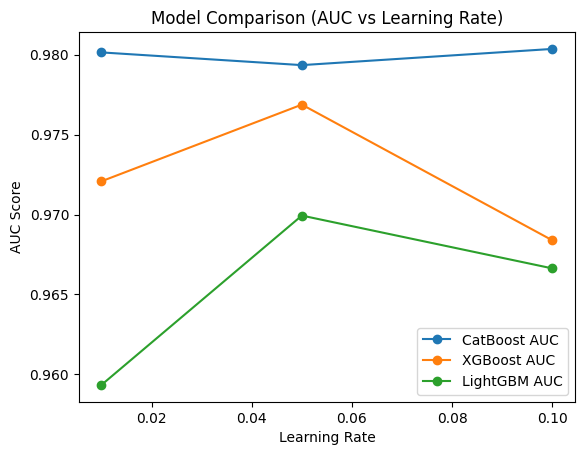

In [14]:
import matplotlib.pyplot as plt

results_df.set_index("Learning Rate").plot(marker='o')
plt.title("Model Comparison (AUC vs Learning Rate)")
plt.ylabel("AUC Score")
plt.show()